In [47]:
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.optimize import minimize, least_squares
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
from tqdm import tqdm
from adjustText import adjust_text

sns.set_style('ticks', rc={"axes.facecolor": (0, 0, 0, 0)})
sns.set_context('talk')

from matplotlib import rcParams
rcParams['font.family'] = 'DejaVu Sans'
#rcParams['font.family'] = 'sans-serif'
#rcParams['font.sans-serif'] = ['Arial']

In [2]:
# Parameters
fc_thresh = 1
p_thresh = 0.05

In [9]:
# Paths
out_dir = Path("../../out/diff_expr/")
data_dir = Path("../../data/reference/")
contrast_file = out_dir / "contrast_table.tsv"
gff = data_dir / "D39.gff"

In [11]:
# Load data
contrasts = pd.read_csv(contrast_file, sep="\t")
ref = pd.read_csv(gff, sep="\t", comment="#", header=None,
                     names=["seqid", "source", "type", "start", "end", "score", "strand", "phase", "attributes"])

In [13]:
# Filter for genes or CDS
genes = ref[ref["type"].isin(["gene", "CDS"])]

# Function to extract attributes
def parse_attributes(attr_str):
    attrs = dict(item.split("=") for item in attr_str.split(";") if "=" in item)
    return pd.Series({
        "locus_tag": attrs.get("locus_tag", ""),
        "gene_id": attrs.get("gene", ""),
        "gene_name": attrs.get("gene_name", ""),
        "product": attrs.get("product", "")
    })

# Apply parsing
gene_attr = genes["attributes"].apply(parse_attributes)

# Combine with positional info
gene_df = pd.concat([genes[["seqid", "start", "end", "strand"]], gene_attr], axis=1)

In [46]:
gene_df["locus_tag"].nunique()

2098

In [44]:
gene_df["gene_id"].nunique()

613

In [113]:
gene_df

,seqid,start,end,strand,locus_tag,gene_id,gene_name,product
1,NC_008533.2,1,1362,+,SPD_RS00005,dnaA,,
2,NC_008533.2,1,1362,+,SPD_RS00005,dnaA,,chromosomal replication initiator protein DnaA
3,NC_008533.2,1521,2657,+,SPD_RS00010,dnaN,,
4,NC_008533.2,1521,2657,+,SPD_RS00010,dnaN,,DNA polymerase III subunit beta
5,NC_008533.2,2722,2916,+,SPD_RS00015,,,
...,...,...,...,...,...,...,...,...
4284,NC_008533.2,2043245,2043724,-,SPD_RS10940,rlmH,,23S rRNA (pseudouridine(1915)-N(3))-methyltran...
4285,NC_008533.2,2043907,2045088,+,SPD_RS10945,,,
4286,NC_008533.2,2043907,2045088,+,SPD_RS10945,,,S1C family serine protease
4287,NC_008533.2,2045146,2045904,+,SPD_RS10950,,,


In [112]:
gene_df.to_csv("../../out/diff_expr/gene_df.tsv", sep="\t", index=None)

In [104]:
def volcano_plot(df, gff_df=None, title="", fc_thresh=1, p_thresh=0.05, save_path=None):
    # Detect fold change column
    fc_cols = [c for c in df.columns if 'log2' in c.lower() and 'fold' in c.lower()]
    if not fc_cols:
        raise ValueError("No log2 fold change column found")
    fc_col = fc_cols[0]

    # Detect adjusted p-value column
    padj_cols = [c for c in df.columns if 'padj' in c.lower()]
    if not padj_cols:
        raise ValueError("No adjusted p-value column found")
    padj_col = padj_cols[0]

    # Detect gene/feature column
    gene_cols = [c for c in df.columns if c.lower() in ['gene','feature_id','id']]
    gene_col = gene_cols[0] if gene_cols else 'gene'
    df['gene'] = df[gene_col]

    # Replace zeros and compute -log10(padj)
    df[padj_col] = df[padj_col].replace(0, 1e-300)
    df['-log10(padj)'] = -np.log10(df[padj_col])

    
    # Create a column for display labels from GFF
    # this would normally keep all labels (locus tag and gene)
    if gff_df is not None:
        # Map: prefer gene_name > gene_id > locus_tag
        label_map = {}
        for _, row in gff_df.iterrows():
            label_map[row['locus_tag']] = row['gene_name'] if row['gene_name'] else (
                                          row['gene_id'] if row['gene_id'] else row['locus_tag'])
        df['label'] = df['gene'].map(label_map).fillna(df['gene'])
    else:
        df['label'] = df['gene'] if 'gene' in df.columns else df.index.astype(str)

    # Assign colors
    df['color'] = np.where(
        (df[padj_col] < p_thresh) & (df[fc_col] > fc_thresh), 'red',
        np.where((df[padj_col] < p_thresh) & (df[fc_col] < -fc_thresh), 'green', 'grey')
    )

    # same alike above, this would keep all labels
    # Top labels to annotate
    keep_labels = df.loc[
        (df[padj_col] < p_thresh) & 
        ((abs(df[fc_col]) > df[fc_col].abs().max()*0.9) | 
         (df['-log10(padj)'] > df['-log10(padj)'].max()*0.9)),
        'label'
    ].tolist()

    plt.figure(figsize=(8,7))
    plt.scatter(df[fc_col], df['-log10(padj)'], c=df['color'], alpha=0.5, edgecolors='none', zorder=1)

    plt.axhline(-np.log10(p_thresh), color='grey', linestyle='--', zorder=2)
    plt.axvline(fc_thresh, color='grey', linestyle='--', zorder=2)
    plt.axvline(-fc_thresh, color='grey', linestyle='--', zorder=2)

    # Annotate
    texts = []
    for gene in keep_labels:
        g_row = df[df['label'] == gene].iloc[0]
        texts.append(plt.text(g_row[fc_col], g_row['-log10(padj)'], gene, fontsize=12))

    adjust_text(texts, 
                arrowprops=dict(arrowstyle='-', color='black', lw=0.25),
                expand_points=(1.2, 1.2),
                force_points=0.2)

    y_min = df['-log10(padj)'].min()
    xlim = max(abs(df[fc_col].max()), abs(df[fc_col].min()))
    plt.xlim(-xlim*1.05, xlim*1.05)
    plt.ylim(-30, df['-log10(padj)'].max()*1.05)

    plt.xlabel("log2 Fold Change")
    plt.ylabel("-log10 adjusted Pvalue")
    plt.title(title, fontsize=16)
    plt.gca().set_facecolor("white")

    if save_path:
        plt.tight_layout()
        plt.savefig(save_path, dpi=300)
    plt.show()

In [110]:
gene_df[gene_df.locus_tag == "SPD_RS01515"]

,seqid,start,end,strand,locus_tag,gene_id,gene_name,product
588,NC_008533.2,274549,275985,+,SPD_RS01515,,,
589,NC_008533.2,274549,275985,+,SPD_RS01515,,,6-phospho-beta-glucosidase


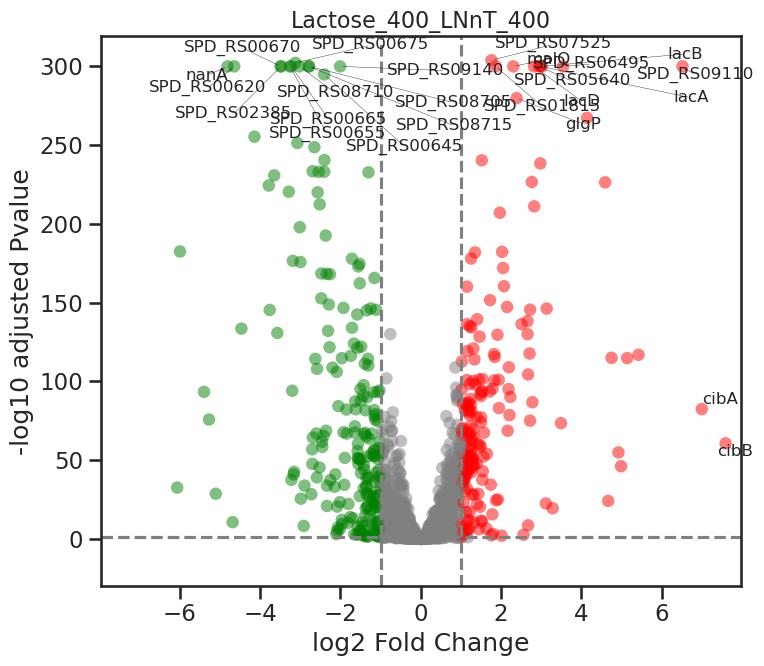

6 [ 0.19422715 -0.26441077]
13 [0.34304547 0.61720398]
6 [ 0.0099755  -0.54960999]
13 [ 0.22353414 -0.06058768]
6 [0.93763294 0.85723305]
13 [-0.73547273 -0.88648325]
6 [-0.18585777  0.86824912]
13 [ 0.29142881 -0.45518083]
6 [ 0.36666498 -0.35232214]
13 [ 0.59025206 -0.5640323 ]
6 [-0.33070346 -0.11423521]
13 [-0.64862795  0.61141133]


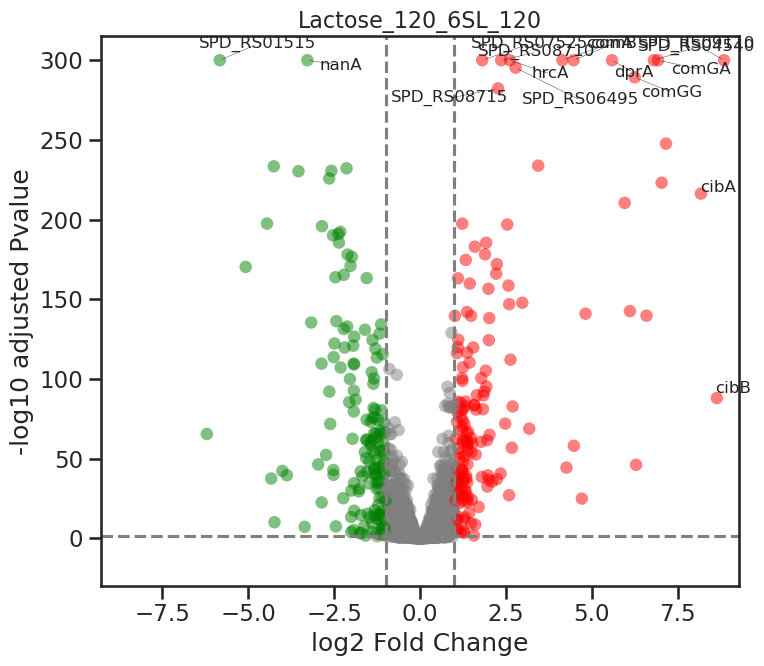

9 [-0.77797527 -0.78143527]
25 [ 0.84769135 -0.5616575 ]
9 [ 0.55333702 -0.76236432]
25 [-0.57643267 -0.84489446]
9 [ 0.14515199 -0.22467862]
25 [0.76996993 0.55313681]
9 [ 0.78964271 -0.82844818]
25 [ 0.22479384 -0.58584406]
9 [-0.8963043   0.21592463]
25 [-0.31046189 -0.82752286]
9 [-0.0090257   0.04650045]
25 [-0.31278253  0.94360156]
9 [-0.97141815  0.49256811]
25 [-0.54006449  0.41330206]
9 [0.88003847 0.9341039 ]
25 [-0.05200999 -0.71813553]
9 [-0.02656369 -0.74038943]
25 [-0.77817372 -0.65513019]
9 [ 0.11017625 -0.24763687]
25 [ 0.51214867 -0.2749995 ]
9 [ 0.12716091 -0.77381106]
25 [-0.16208872  0.4567634 ]
9 [ 0.43650121 -0.40299909]
25 [-0.27688954 -0.03226965]
9 [-0.06328248  0.18097665]
25 [-0.84664557  0.0629898 ]
9 [ 0.09018133 -0.7810779 ]
25 [ 0.10783608 -0.20033169]
9 [-0.20626906  0.17739576]
25 [0.40234678 0.36381859]
9 [0.84635951 0.10359118]
25 [0.92941533 0.55514957]
9 [-0.11260754 -0.97039059]
25 [0.95854956 0.91972227]
9 [-0.21598342  0.48204208]
25 [ 0.54281788

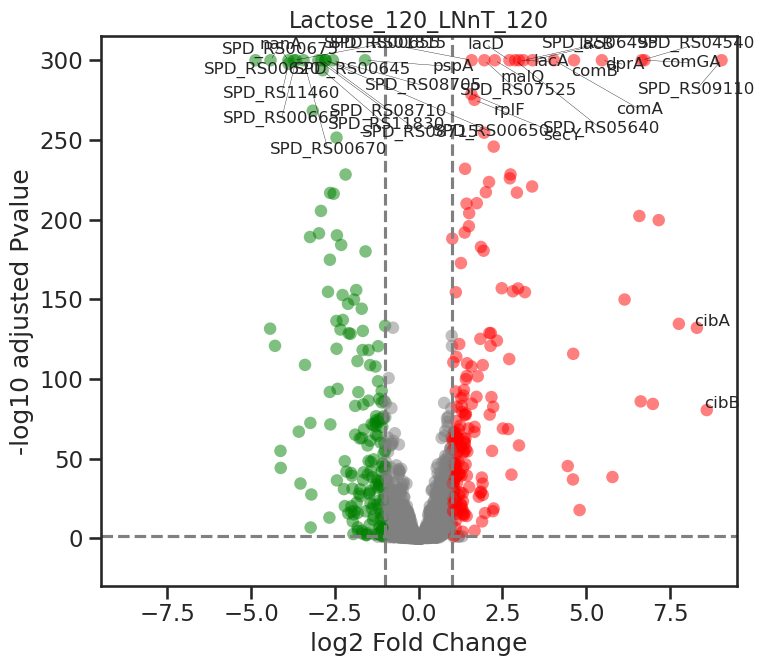

7 [-0.8123319  -0.59791944]
8 [-0.11251478 -0.94345353]
9 [-0.18053112  0.24994741]
10 [0.60863886 0.54937345]


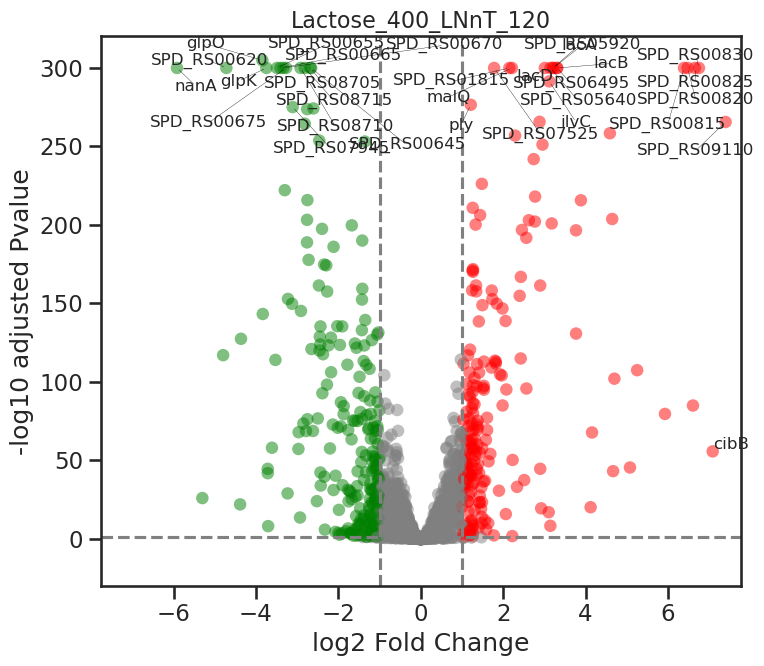

3 [-0.61043093  0.16011481]
11 [-0.37453023  0.43936123]
3 [-0.31843686 -0.31496647]
11 [-0.91612166 -0.23084785]


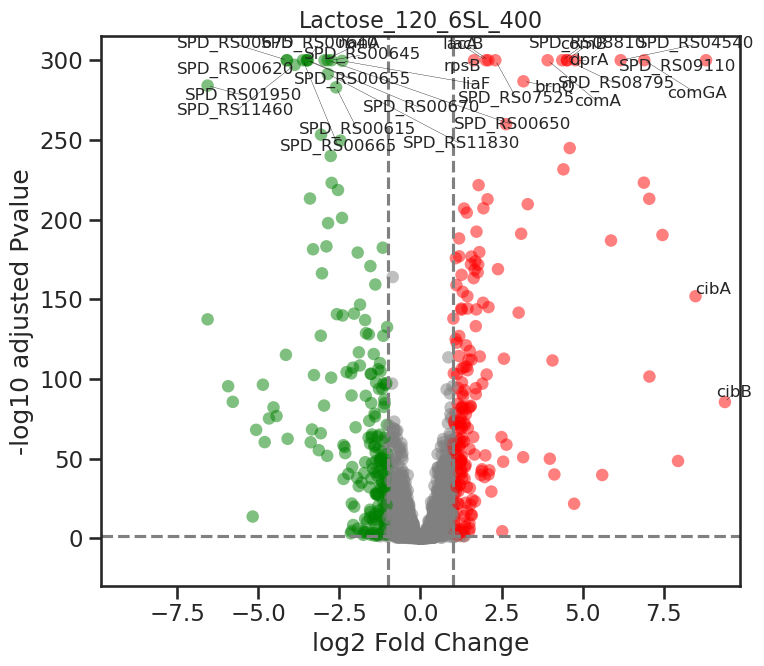

2 [0.52551024 0.99135949]
7 [-0.18787971 -0.71931399]
2 [-0.64797986 -0.73344178]
7 [-0.38527216  0.31173365]
2 [-0.9668051  -0.97816908]
7 [ 0.36377816 -0.14364107]
6 [0.67499926 0.0070718 ]
7 [-0.75591191  0.32173993]
6 [ 0.15524934 -0.00437252]
7 [-0.41858988 -0.94521045]
6 [-0.66055495 -0.39672281]
7 [-0.13681664 -0.94160956]
6 [0.55142912 0.52907976]
7 [-0.00845461  0.31695598]
6 [-0.98394814 -0.51196211]
7 [ 0.67025015 -0.83615302]
6 [-0.87926581 -0.15729414]
7 [0.72028696 0.60456175]
6 [-0.03648061 -0.52872076]
7 [ 0.79842992 -0.83883246]
6 [ 0.62589631 -0.06317987]
7 [0.4590593  0.39668394]
6 [-0.28364236 -0.38892423]
7 [ 0.78814957 -0.46275852]
6 [0.57160156 0.38083026]
7 [ 0.92148818 -0.11871758]
6 [ 0.07714661 -0.77580147]
7 [ 0.80664352 -0.49555511]
6 [ 0.08215416 -0.76007124]
7 [0.88291261 0.65854005]
6 [ 0.69207945 -0.22083367]
7 [0.45466446 0.91434196]
6 [0.43892827 0.66504707]
7 [0.03054359 0.72365313]
6 [0.60191902 0.29513111]
7 [-0.24292664 -0.88866856]
6 [0.61980663 

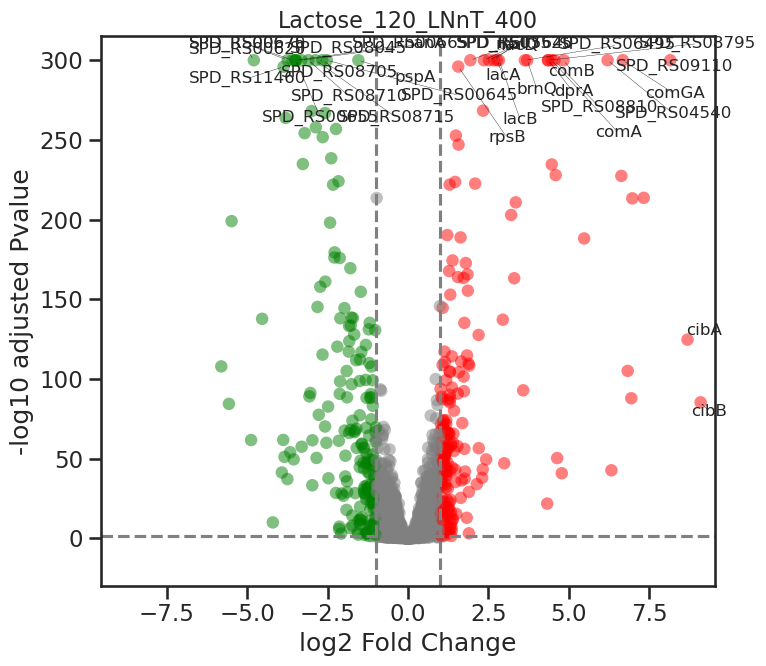

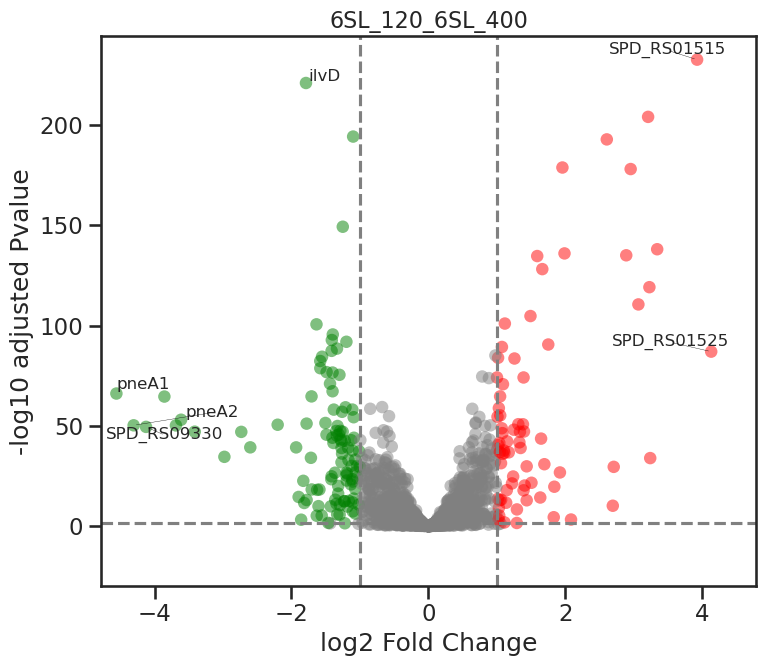

0 [ 0.43397044 -0.19532097]
3 [0.13728278 0.94813951]


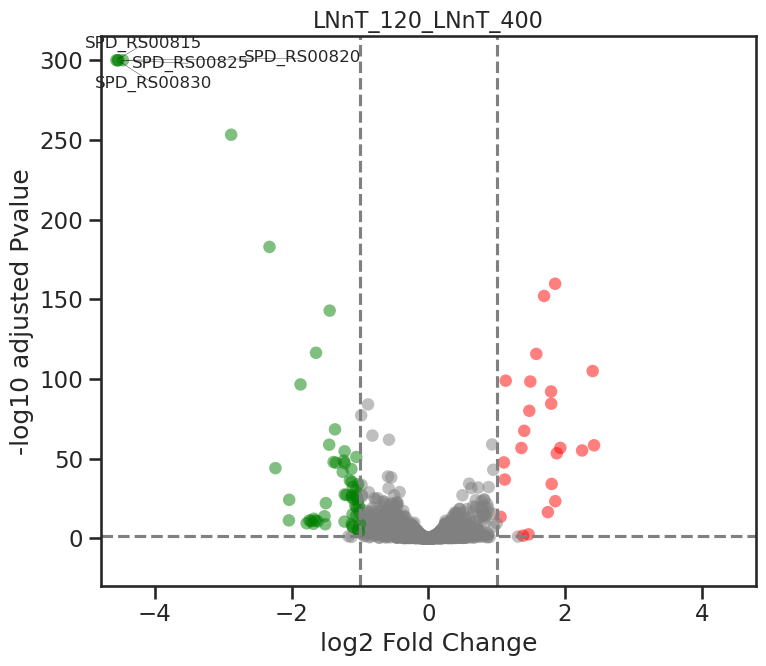

2 [ 0.9127708  -0.39307807]
10 [ 0.42132125 -0.83047828]
4 [-0.21066214 -0.48576394]
5 [ 0.37419794 -0.27659682]
2 [ 0.43691292 -0.62021283]
5 [-0.02010345 -0.70710438]
2 [0.01229876 0.42866732]
10 [0.62071568 0.7830892 ]
2 [-0.6424535  -0.57137568]
10 [0.32952234 0.81440039]
2 [-0.15229425  0.47876177]
10 [ 0.99610975 -0.57829244]
2 [-0.01054989  0.82284995]
10 [ 0.68721484 -0.7066717 ]


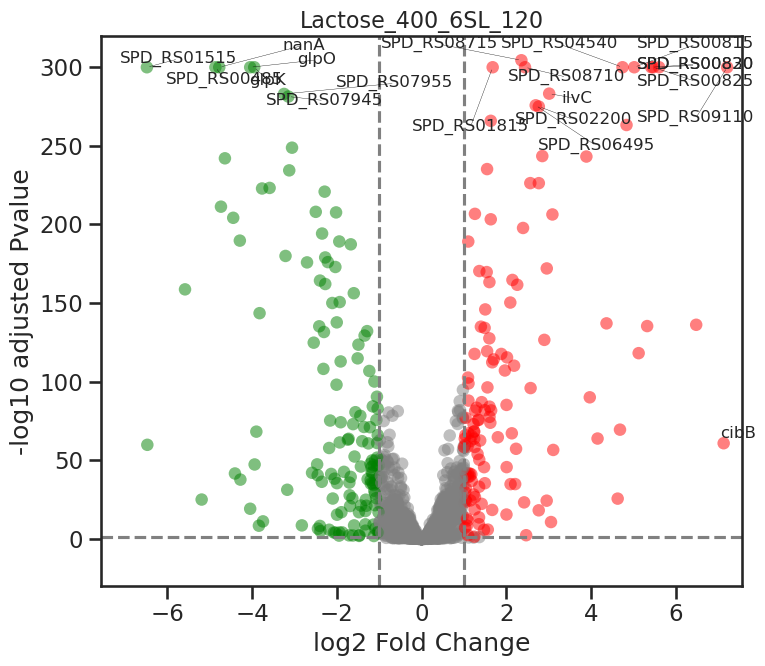

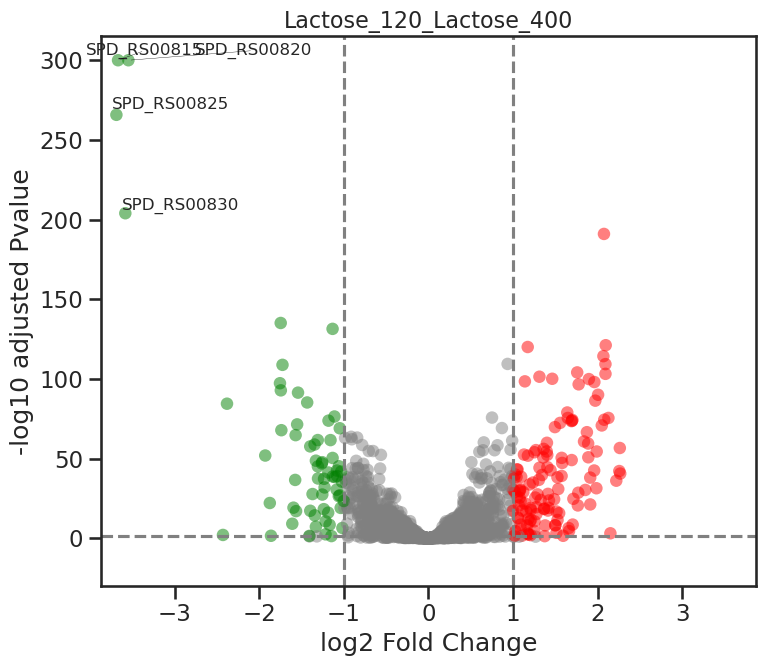

12 [-0.09760881 -0.75187609]
14 [-0.42869425  0.63664195]
12 [-0.89755289 -0.6243154 ]
14 [-0.62382888  0.81869853]
15 [ 0.82351478 -0.2201752 ]
12 [ 0.98436146 -0.32418837]
14 [-0.0501661  0.2672813]
15 [-0.69839924 -0.82690992]
12 [-0.73630231  0.11051094]
14 [-0.12495501 -0.07207281]
15 [ 0.01253438 -0.0945189 ]
14 [0.12520675 0.62481783]
15 [-0.85678205 -0.86928489]
12 [ 0.66734468 -0.67679657]
14 [0.00753201 0.64069324]
12 [ 0.41042266 -0.76062032]
14 [ 0.15101891 -0.88591687]
12 [-0.60917748  0.79312095]
14 [ 0.32786555 -0.77986767]
12 [0.32708273 0.58398436]
14 [0.38889879 0.04467753]
12 [ 0.69310075 -0.81528913]
14 [0.54088278 0.25361678]


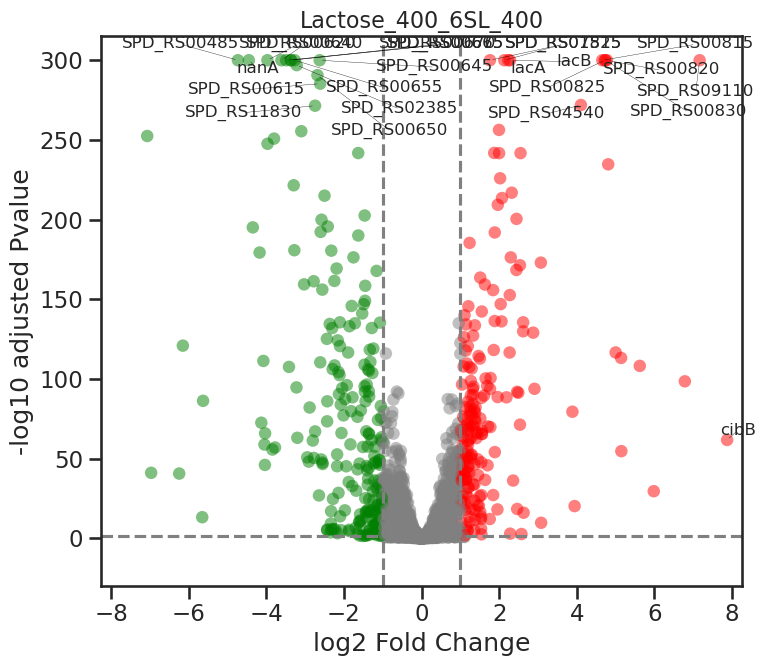

In [105]:
# Loop through DGE files
for file in out_dir.glob("DGE_*.tsv"):
    df = pd.read_csv(file, sep="\t")
    contrast_name = file.stem.replace("DGE_", "")
    volcano_plot(df, title=contrast_name, gff_df=gene_df,
                 fc_thresh=fc_thresh, p_thresh=p_thresh,
                 save_path=out_dir / f"annotated_volcano_plot_{contrast_name}.png")